# Running the nonadiabatic molecular dynamics (NA-MD)

In this tutorial, we conduct NBRA NA-MD calculations using the Libra code. This version implements the generic dynamical approach that is common to model-based NA-MD simulations and the one based on reading files. In this particular case, we setup the interface to pre-computed energy and time-overlap files produced by openmolcas and use it in the generic dynamical workflow.

Table of contents:

1. Importing needed libraries

2. Read the files in a selected basis

3. Computing the average energy gaps and decoherence times

4. Define the interface

5. Define the parameters

6. Run NAMD simulations

7. Plot results

8. Additional descriptive analysis: Pre-dynamics


# Learning objectives
To set up and run file-based NBRA NA-MD calculations with different methods

To be able to plot the decoherence times map

To be able to plot and analyze NAMD results

# 1. Importing needed libraries

First, let's import all necessary libraries and define parameters such as colors

In [250]:
import os, glob, time, h5py, warnings
import multiprocessing as mp
import matplotlib.pyplot as plt   # plots
import matplotlib.ticker as ticker
import numpy as np
import scipy.sparse as sp
from scipy.optimize import curve_fit
from liblibra_core import *
import util.libutil as comn
from libra_py import units, data_conv, dynamics_plotting
import libra_py.dynamics.tsh.compute as tsh_dynamics
import libra_py.dynamics.tsh.plot as tsh_dynamics_plot
import libra_py.data_savers as data_savers
import libra_py.workflows.nbra.decoherence_times as decoherence_times
import libra_py.data_visualize

 
%matplotlib inline
warnings.filterwarnings('ignore')

colors = {}
colors.update({"11": "#8b1a0e"})  # red       
colors.update({"12": "#FF4500"})  # orangered 
colors.update({"13": "#B22222"})  # firebrick 
colors.update({"14": "#DC143C"})  # crimson   
colors.update({"21": "#5e9c36"})  # green
colors.update({"22": "#006400"})  # darkgreen  
colors.update({"23": "#228B22"})  # forestgreen
colors.update({"24": "#808000"})  # olive      
colors.update({"31": "#8A2BE2"})  # blueviolet
colors.update({"32": "#00008B"})  # darkblue  
colors.update({"41": "#2F4F4F"})  # darkslategray

clrs_index = ["11", "21", "31", "41", "12", "22", "32", "13","23", "14", "24"]

# 2. Read the files in a selected basis

Here, we will be reading the files required for NBRA-NAMD simulations. For convenience, we'll define two functions and will be calling them with the appropriate inuts as needed.

Both functions have the parameters:

istep: The initial step index

fstep: The final step index

data_path : The path to the data folder containing all the needed files

Note: that all the files from istep to fstep-1 should exist.

The function returns:

NSTEPS: Number of steps which is fstep-istep

NSTATES : the number of states

St_adi, Ham_adi, Hvib_adi, NAC_adi, Basis_transform : list of CMATRIX objects containing data for all timesteps. These are the global storage for later reuse by the TSH workflow.

In [251]:
def read_files_new(data_path, istep, fstep):

    nsteps = fstep - istep
    NSTEPS = nsteps
    print(F"Number of steps = {NSTEPS}")

    # ================= Reading the data ======================
    # Get the number of states:
    st = np.loadtxt(F"{data_path}/st_adi_{istep}.txt")
    NSTATES = st.shape[0]
    print(F"NSTATES = {NSTATES}")

    #==== Read time-overlap, adiabatic Hamiltonians and vibronic Hamiltonians ==========
    St_adi, Ham_adi, Hvib_adi, NAC_adi, Basis_transform = [], [], [], [], []
    for i in range(istep,fstep):

        # Time-overlaps
        st = CMATRIX(NSTATES,NSTATES)
        st.Load_Matrix_From_File(F"{data_path}/st_adi_{i}.txt")
        St_adi.append(st)

        # Adiabatic Hamiltonian
        ham_adi = CMATRIX(NSTATES,NSTATES)
        ham_adi.Load_Matrix_From_File(F"{data_path}/ham_adi_{i}.txt")
        Ham_adi.append(ham_adi)

        # Adiabatic vibronic Hamiltonian
        #hvib_adi = CMATRIX(NSTATES,NSTATES)
        #hvib_adi.Load_Matrix_From_File(F"{data_path}/hvib_adi_{i}.txt")
        #Hvib_adi.append(hvib_adi)

        # NACs
        #nac_adi =  (ham_adi - hvib_adi)*(0.0+1.0j)
        dt = 0.5*units.fs2au
        nac_adi = (st - st.H())/(2.0*dt)
        NAC_adi.append(nac_adi)

        # Adiabatic vibronic Hamiltonian
        hvib_adi = CMATRIX(NSTATES,NSTATES)
        #hvib_adi.Load_Matrix_From_File(F"{data_path}/hvib_adi_{i}.txt")
        hvib_adi = ham_adi - nac_adi*(0.0+1.0j)
        Hvib_adi.append(hvib_adi)

        # Basis transform
        bas_trans = CMATRIX(NSTATES, NSTATES);  bas_trans.identity()
        Basis_transform.append(bas_trans)

    return NSTEPS, NSTATES, St_adi, Ham_adi, Hvib_adi, NAC_adi, Basis_transform


Data Read

new style data files (.txt)

data in path 'results_molcas'

istep=0, fstep=49

3 states

dt = 1.0 fs

In [252]:
##================ Example 2 (New) ======================
# Uncomment this line, if you need the data files
#!tar -xf data2.tar.bz2

data_path = 'results_molcas'
istep = 0    # the first timestep to read
fstep = 49 # the last timestep to read
ISTATE = 2

NSTEPS, NSTATES, St_adi, Ham_adi, Hvib_adi, NAC_adi, Basis_transform = read_files_new(data_path, istep, fstep)

Number of steps = 49
NSTATES = 3


# 3. Computing the average energy gaps and decoherence times

Below, we compute the average energy gaps and decoherence times between all states. The average gaps matrix, gaps, and average decoherence times and rates, avg_deco and rates, are required for NAMD with decoherence methods.

In [253]:
# ================= Computing the energy gaps and decoherence times
# Average decoherence times and rates
tau, rates = decoherence_times.decoherence_times_ave([Hvib_adi], [0], len(Hvib_adi), 0)

# Computes the energy gaps between all states for all steps
dE = decoherence_times.energy_gaps_ave([Ham_adi], [0], len(Ham_adi))

# Decoherence times in fs
deco_times = data_conv.MATRIX2nparray(tau) * units.au2fs

# Zero all the diagonal elements of the decoherence matrix
np.fill_diagonal(deco_times, 0)

# Saving the average decoherence times
np.savetxt('decoherence_times.txt',deco_times.real)

# Computing the average energy gaps
gaps = MATRIX(NSTATES, NSTATES)
for step in range(NSTEPS):
    gaps += dE[step]
gaps /= NSTEPS

rates.show_matrix("decoherence_rates.txt")
gaps.show_matrix("average_gaps.txt")

# 4. Define the interface

The interface function should be defined as explained in other tutorials. It should return objects with the specifically-named data members. This is what we defined here:

In [254]:
class abstr_class:
    pass

def compute_model(q, params, full_id):
    timestep = params["timestep"]
    
    obj = abstr_class()    
    obj.ham_adi = Ham_adi[timestep]
    obj.hvib_adi = Hvib_adi[timestep]
    obj.nac_adi = NAC_adi[timestep]
    obj.basis_transform = Basis_transform[timestep]
    obj.time_overlap_adi = St_adi[timestep]

    return obj

# 5. Define the parameters

Make sure you define all of these 4 parameters of the model_params dictionary. Here, we first initialize the parameter timestep to 0. This parameter will be updated to icond which is representative of the initial geomtery.

In [255]:
#================== Model parameters ====================
model_params = { "timestep":0, "icond":0,  "model0":0, "nstates":NSTATES }

Dynamics control parameters are as follows:

nfiles: The total number of files that was read.

nsteps: The total number of steps for dynamics. Note that this number can be larger than the number of files nfiles read. For nsteps more than nfiles, Libra will repeat the Hamiltonian matrices and do the dynamics.

ntraj: The number of surface hopping trajectories.

dt: The time step in atomic units.

decoherence_rates: The matrix of dephasing rates with a unit of a.u. of time-1
.

ave_gaps: A matrix that contains the averaged moduli of the energy gaps

Eij = |Ei-Ej|


It is needed when dephasing_informed option is used, like DISH method.

progress_frequency: At what intervals print out some "progress" messages. For instance, if you have nsteps = 100 and progress_frequency = 0.1, the code will notify you every 10 steps.

which_adi_states: Indices of the adiabatic states to plot.

which_dia_states: Indices of the diabatic states to plot.

mem_output_level: Controls what info to save into HDF5 files (all at the end) Same meaning and output as with hdf5_output_level, except all the variables are first stored in memory (while the calcs are running) and then they are written into the HDF5 file at the end of the calculations. This is a much faster version of hdf5 saver.

properties_to_save: Describes what properties to save to the HDF5 files. Note that if some properties are not listed in this variable, then they are not saved, even if mem_output_level suggests they may be saved. You need to BOTH set the appropriate mem_output_level AND properties_to_save:

default:

[ "timestep", "time", "Ekin_ave", "Epot_ave", "Etot_ave", 
         "dEkin_ave", "dEpot_ave", "dEtot_ave", "states", "SH_pop", "SH_pop_raw",
         "D_adi", "D_adi_raw", "D_dia", "D_dia_raw", "q", "p", "Cadi", "Cdia", 
         "hvib_adi", "hvib_dia", "St", "basis_transform", "projector"]
         
         
prefix: The name of the folder to be created by this function. All the data files will be created in that folder.

isNBRA: A flag for NBRA type of calculations.

Other parameters for NBRA-specific parameters are explained in the comments of the cell below

In [256]:
#=============== Some automatic variables, related to the settings above ===================
dyn_general = { "nsteps":NSTEPS*2, "ntraj":200, "nstates":NSTATES, "dt":1.0*units.fs2au, "nfiles": NSTEPS,
                "decoherence_rates":rates, "ave_gaps": gaps,
                "progress_frequency":0.1, "which_adi_states":range(NSTATES), "which_dia_states":range(NSTATES),
                "mem_output_level":2,
                "properties_to_save":[ "timestep", "time","se_pop_adi", "sh_pop_adi", "Epot_ave",  "se_pop_dia", "sh_pop_dia" ],
                "prefix":F"NBRA", "isNBRA":0
              }

# Uncomment one of the options in each of the categories below:
#====== How to update Hamiltonian ===================
#dyn_general.update({"ham_update_method":0}) # don't update any Hamiltonians
#dyn_general.update({"ham_update_method":1})  # recompute only diabatic Hamiltonian, common choice for model Hamiltonians
dyn_general.update({"ham_update_method":2})  # recompute only adiabatic Hamiltonian; use with file-based or on-the-fly workflows


#====== How to transform the Hamiltonians between representations ============
dyn_general.update( {"ham_transform_method":0 }) # don't do any transforms; usually for NBRA or on-the-fly workflows,
                                                 # so you don't override the read values
#dyn_general.update( {"ham_transform_method":1 }) # diabatic->adiabatic according to internal diagonalization
#dyn_general.update( {"ham_transform_method":2 }) # diabatic->adiabatic according to internally stored basis transformation matrix
#dyn_general.update( {"ham_transform_method":3 }) # adiabatic->diabatic according to internally stored basis transformation matrix
#dyn_general.update( {"ham_transform_method":4 }) # adiabatic->diabatic according to local diabatization method

#====== How do get the time-overlaps in the dynamics ========
dyn_general.update( {"time_overlap_method":0 })  # don't update time-overlaps - maybe they are already pre-computed and read
#dyn_general.update( {"time_overlap_method":1 }) # explicitly compute it from the wavefunction info; common for model Hamiltonians

#================== How to compute NACs ===============================
#dyn_general.update({"nac_update_method":0 })  # just read from files
#dyn_general.update({"nac_update_method":1})  # explicit NAC calculations - let's just focus on this one for now
dyn_general.update({"nac_update_method":2, "nac_algo":0})  # HST algo
#dyn_general.update({"nac_update_method":2, "nac_algo":1})  # NPI algo

#============== How to compute vibronic Hamiltonian ==============
dyn_general.update( {"hvib_update_method":0 }) # don't update Hvib; maybe because we read it from files
#dyn_general.update( {"hvib_update_method":1 }) # recompute diabatic and adiabatic Hvib from the Ham and NACs in those reps

#=========== Ehrenfest or state-resolved options ===========
# This is what we use with any of the TSH-based methods - in all cases here, we would
# use "rep_force":1 so that we are guided by the forces derived from the adiabatic surfaces.
# In Ehrenfest cases though, the forces can be computed using only diabatic properties though
dyn_general.update( {"force_method":0, "rep_force":1} ) # don't compute forces
#dyn_general.update( {"force_method":1, "rep_force":1} ) # state-resolved (e.g. TSH) with adiabatic forces
#dyn_general.update( {"force_method":2, "rep_force":1} ) # for Ehrenfest in adiabatic rep
#dyn_general.update( {"force_method":2, "rep_force":0} ) # for Ehrenfest in diabatic rep

#============ Types of surface hopping acceptance and momenta rescaling opntions =================
#dyn_general.update({"hop_acceptance_algo":10, "momenta_rescaling_algo":100 })  # accept and rescale based on total energy, do not reverse on frustrated
#dyn_general.update({"hop_acceptance_algo":10, "momenta_rescaling_algo":101 })  # accept and rescale based on total energy, reverse on frustrated
#dyn_general.update({"hop_acceptance_algo":20, "momenta_rescaling_algo":200 })  # accept and rescale based on NAC vectors, do not reverse on frustrated
#dyn_general.update({"hop_acceptance_algo":20, "momenta_rescaling_algo":201 })  # accept and rescale based on NAC vectors, reverse on frustrated
#dyn_general.update({"hop_acceptance_algo":21, "momenta_rescaling_algo":200 })  # accept and rescale based on force differences, do not reverse on frustrated
#dyn_general.update({"hop_acceptance_algo":21, "momenta_rescaling_algo":201 })  # accept and rescale based on force differences, reverse on frustrated
dyn_general.update({"hop_acceptance_algo":31, "momenta_rescaling_algo":0 })  # accept and rescale based on total energy, reverse on frustrated

#============ Surface hopping opntions =================
#dyn_general.update({"tsh_method":-1 }) # adiabatic, no surface hopping
dyn_general.update({"tsh_method":0 }) # FSSH
#dyn_general.update({"tsh_method":1 }) # GFSH
#dyn_general.update({"tsh_method":2 }) # MSSH
#dyn_general.update({"tsh_method":3, "rep_lz":0 })  # LZ options
#dyn_general.update({"tsh_method":4, "rep_lz":0 }) # ZN
#dyn_general.update({"tsh_method":5 }) # DISH
#dyn_general.update({"tsh_method":6 }) # MASH
#dyn_general.update({"tsh_method":7 }) # FSSH2
#dyn_general.update({"tsh_method":8 }) # GFSH (original)

#=========== Decoherence options =================
dyn_general.update({ "decoherence_algo":-1}) # no (additional) decoherence
#dyn_general.update({ "decoherence_algo":0}) # SDM and alike
#dyn_general.update({ "decoherence_algo":1}) # IDA (ID-S, ID-A, ID-C)
#dyn_general.update({ "decoherence_algo":2}) # A-FSSH, not yet ready
#dyn_general.update({ "decoherence_algo":3}) # BCSH
#dyn_general.update({ "decoherence_algo":4}) # MF-SD
#dyn_general.update({ "decoherence_algo":5}) # SHXF
#dyn_general.update({ "decoherence_algo":6}) # MQCXF
#dyn_general.update({ "decoherence_algo":7}) # DISH, rev2023

#=========== Decoherence times (for decoherence options 0 or 4) ==================
dyn_general.update({"decoherence_times_type":-1 }) # No decoherence times, infinite decoherence times
#dyn_general.update( { "decoherence_times_type":0 } )  # manual decoherence times
#dyn_general.update( { "decoherence_times_type":1, "decoherence_C_param": 1.0, "decoherence_eps_param":0.1 } )  # EDC + default params
#dyn_general.update( { "decoherence_times_type":2, "schwartz_decoherence_inv_alpha":A } ) # Schwartz version 1
#dyn_general.update( { "decoherence_times_type":3, "schwartz_decoherence_inv_alpha":A } ) # Schwartz version 2

#======= Various decoherence-related parameters =====================
dyn_general.update( {"dephasing_informed":0 } ) #, "decoherence_rates":MATRIX(2,2), "ave_gaps":MATRIX(2,2) } )

#======= DISH-specific ======================
dyn_general.update( {"dish_decoherence_event_option":1} )

#=========== Phase correction of SSY =================
dyn_general.update({"do_ssy":0 }) # do no use it - that's the default

#=========== What to integrate ==================
# solve TD-SE in diabatic representation
#dyn_general.update({"rep_tdse":0, "electronic_integrator":-1 })   # no propagation
#dyn_general.update({"rep_tdse":0, "electronic_integrator":0 })    # Lowdin exp_ with 2-point Hvib_dia
#dyn_general.update({"rep_tdse":0, "electronic_integrator":1 })    # based on QTAG propagator
#dyn_general.update({"rep_tdse":0, "electronic_integrator":2 })    # based on modified QTAG propagator (Z at two times)
#dyn_general.update({"rep_tdse":0, "electronic_integrator":3 })    # non-Hermitian integrator with 2-point Hvib_dia

# solve TD-SE in adiabatic representation
#dyn_general.update({"rep_tdse":1, "electronic_integrator":-1 })  # no propagation
#dyn_general.update({"rep_tdse":1, "electronic_integrator":0 })   # ld, with crude splitting,  with exp_
#dyn_general.update({"rep_tdse":1, "electronic_integrator":1 })   # ld, with symmetric splitting, with exp_
#dyn_general.update({"rep_tdse":1, "electronic_integrator":2 })   # ld, original, with exp_
#dyn_general.update({"rep_tdse":1, "electronic_integrator":4 })   # 2-points, Hvib integration, with exp_
dyn_general.update({"rep_tdse":1, "electronic_integrator":5 })   # 2-points, Hvib, integration with the second-point correction of Hvib, with exp_
#dyn_general.update({"rep_tdse":1, "electronic_integrator":6 })   # same as 4, but without projection matrices (T_new = I)
#dyn_general.update({"rep_tdse":1, "electronic_integrator":10 })  # same as 0, but with rotations
#dyn_general.update({"rep_tdse":1, "electronic_integrator":11 })  # same as 1, but with rotations
#dyn_general.update({"rep_tdse":1, "electronic_integrator":12 })  # same as 2, but with rotations
#dyn_general.update({"rep_tdse":1, "electronic_integrator":13 })  # same as 3, but with rotations
#dyn_general.update({"rep_tdse":1, "electronic_integrator":14 })  # same as 4, but with rotations
#dyn_general.update({"rep_tdse":1, "electronic_integrator":15 })  # same as 5, but with rotations

# solve QCLE in diabatic representation
#dyn_general.update({"rep_tdse":3, "electronic_integrator":0 })  # mid-point Hvib, using exp_

# solve QCLE in adiabatic representation
#dyn_general.update({"rep_tdse":3, "electronic_integrator":0 })  # mid-point Ham with the second-point correction of Hvib, using exp_
#dyn_general.update({"rep_tdse":3, "electronic_integrator":1 })  # using Zhu Liouvillian THIS IS NOT JUST A DIFFERENT INTEGRATOR!!!!
#dyn_general.update({"rep_tdse":3, "electronic_integrator":10 }) # same as 0 but with rotations

#=========== Disable state tracking and phase corrections explicitly for the LD integrators ===============
#State tracking algorithm:
#  - -1: use LD approach, it includes phase correction too [ default ]
#  - 0: no state tracking
#  - 1: method of Kosuke Sato (may fail by getting trapped into an infinite loop)
#  - 2: Munkres-Kuhn (Hungarian) algorithm
#  - 21: ChatGPT-generated Munkres-Kuhn (Hungarian) algorithm
#  - 3: experimental stochastic algorithm, the original version with elimination (known problems)
#  - 32: experimental stochastic algorithms with all permutations (too expensive)
#  - 33: the improved stochastic algorithm with good scaling and performance, on par with the mincost
#  - 4: new, experimental force-based tracking
#dyn_general.update({"state_tracking_algo":-1 })
dyn_general.update({"state_tracking_algo":21 })
#dyn_general.update( {"state_tracking_algo":5 })



dyn_general.update({"MK_scaling_function":1})
dyn_general.update({"MK_alpha":1100.0})


#The algorithm to correct phases on adiabatic states
#
#Options:
#  - 0: no phase correction
#  - 1: according to our phase correction algorithm [ default ]
# phase correction doesn't matter, if we use the LD integrator
#dyn_general.update({"do_phase_correction":0 })
dyn_general.update({"do_phase_correction":1 })

#New phase correction, directly applied to NACs. Intended to be used mostly with state_tracking_algo == 4,
#although can be useful with other state treacking algorithms. Should not be used together with
#`do_phase_correction`
#Options:
#  - 0: no correction [ default ]
#  - 1: do this correction
dyn_general.update({"do_nac_phase_correction":0 })
#dyn_general.update({"do_nac_phase_correction":1 })


Now, we define the nuclear and electronic parameters. The nuclear parameters do not matter in the NBRA-NAMD. The initial state is defined in the elec_params with the istate parameter. rep shows in which representation the dynamics should be done where 1 is the adiabatic representation and 0 shows the dynamics in diabatic representation.

Other parameters in the elec_params are used for density matrix and amplitudes initialization.

In [258]:
#=================== Dynamics =======================
# Nuclear DOF - these parameters don't matter much in the NBRA calculations
nucl_params = {"ndof":1, "init_type":3, "q":[-10.0], "p":[0.0], "mass":[2000.0], "force_constant":[0.01], "verbosity":-1 }

# Amplitudes are sampled
elec_params = {"ndia":NSTATES, "nadi":NSTATES, "verbosity":-1, "init_dm_type":0}

elec_params.update( {"init_type":1,  "rep":1,  "istate":ISTATE } )  # how to initialize: random phase, adiabatic representation, given initial state

# 6. Run NAMD simulation

Here, we will conduct NAMD calculations using only one method - the FSSH, to focus on the practice of doing such calculations. We need to define the key parameters in dyn_general. We run the calculations for initial conditions in range(0,200,25). For running each calculations we update the prefix to F'{method}_NBRA_icond_{icond}'. We then will be using these folders and date stored in them to plot the dynamics and compute the timescales.

In [259]:
ICONDS = [0]   #list(range(0,1999,400))

 Run all initial conditions in a consecutive way

In [260]:
%%time 
rnd = Random()

for icond in ICONDS:
    print('Running the calculations for icond:', icond)
    model_params.update({"icond": icond})
    dyn_general.update({"prefix":F"FSSH_NBRA_icond_{icond}"})
    res = tsh_dynamics.generic_recipe(dyn_general, compute_model, model_params, elec_params, nucl_params, rnd)

Running the calculations for icond: 0
Active states (adiabatic)
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
Initial adiabatic populations
[0.0, 0.0, 1.0]
 defined! in the input parametersUse the default value 
WARNINIG in init_auxiliary_variables:           the init_type = 1 is not known. Allowed values are: [0]
 step= 14
 step= 28
 step= 42
 step= 56
 step= 70
 step= 84
 step= 98
 step= 112
 step= 126
 step= 140
In mem_saver.save_data()
d

With pooling - using multiprocessing

We first define the function to be executed

In [261]:
def function1(icond):
    prf = "FSSH"
    
    time.sleep(icond * 0.1 )
    rnd = Random()

    mdl = dict(model_params)
    mdl.update({"icond": icond})  #create separate cop
    dyn_gen = dict(dyn_general)
    
    dyn_gen.update({"prefix":F"{prf}_icond_{icond}", "prefix2":F"{prf}_icond_{icond}" })
    res = tsh_dynamics.generic_recipe(dyn_gen, compute_model, mdl, elec_params, nucl_params, rnd)

And then we run a pool of processes - for various initial conditions

In [262]:
%%time

################################
nthreads = 4
################################
pool = mp.Pool(nthreads)
pool.map(function1, ICONDS)
pool.close()
pool.join()

Active states (adiabatic)
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
Initial adiabatic populations
[0.0, 0.0, 1.0]
 step= 0
 step= 14
 step= 28
 step= 42
Parameter fssh3_approach_option is not defined! in the input parametersUse the default value 
In cctor: lvl = 1 der_lvl = 2
WARNINIG in init_auxiliary_variables:           the init_type = 1 is not known. Allowed values are: [0]


 step= 70
 step= 84
 step= 98
 step= 112
 step= 126
 step= 140
In mem_saver.save_data()
data_name =  ['timestep', 'time', 'se_pop_adi', 'sh_pop_adi', 'Epot_ave', 'se_pop_dia', 'sh_pop_dia']
keywords =  ['timestep', 'time', 'se_pop_adi', 'sh_pop_adi', 'Epot_ave', 'se_pop_dia', 'sh_pop_dia']
keys =  dict_keys(['timestep', 'time', 'Epot_ave', 'se_pop_adi', 'se_pop_dia', 'sh_pop_adi', 'sh_pop_dia'])
Saving the dataset named timestep/data
Saving the dataset named time/data
Saving the dataset named se_pop_adi/data
Saving the dataset named sh_pop_adi/data
Saving the dataset named Epot_ave/data
Saving the dataset named se_pop_dia/data
Saving the dataset named sh_pop_dia/data
CPU times: user 31.3 ms, sys: 81.1 ms, total: 112 ms
Wall time: 728 ms


# 7. Plot results

Plot the results using plot_dynamics

In this cell, we use the function tsh_dynamics_plot.plot_dynamics to plot the dynamics for only one initial condition, icond:0. The user can change the range of states to be plotted by changing which_adi_states. The rest of the parameters are used for plotting and are descriptive. Here, we only plot the dynamics for FSSH and the first initial condition.

Here, we are going to compare the results printed into different folders:

FSSH_NBRA_icond_0 - from the sequential execution of all initial conditions

FSSH_icond_0 - from the pool-based execution of all initial conditions

Parameter fssh3_approach_option is not defined! in the input parametersUse the default value 
In cctor: lvl = 1 der_lvl = 2

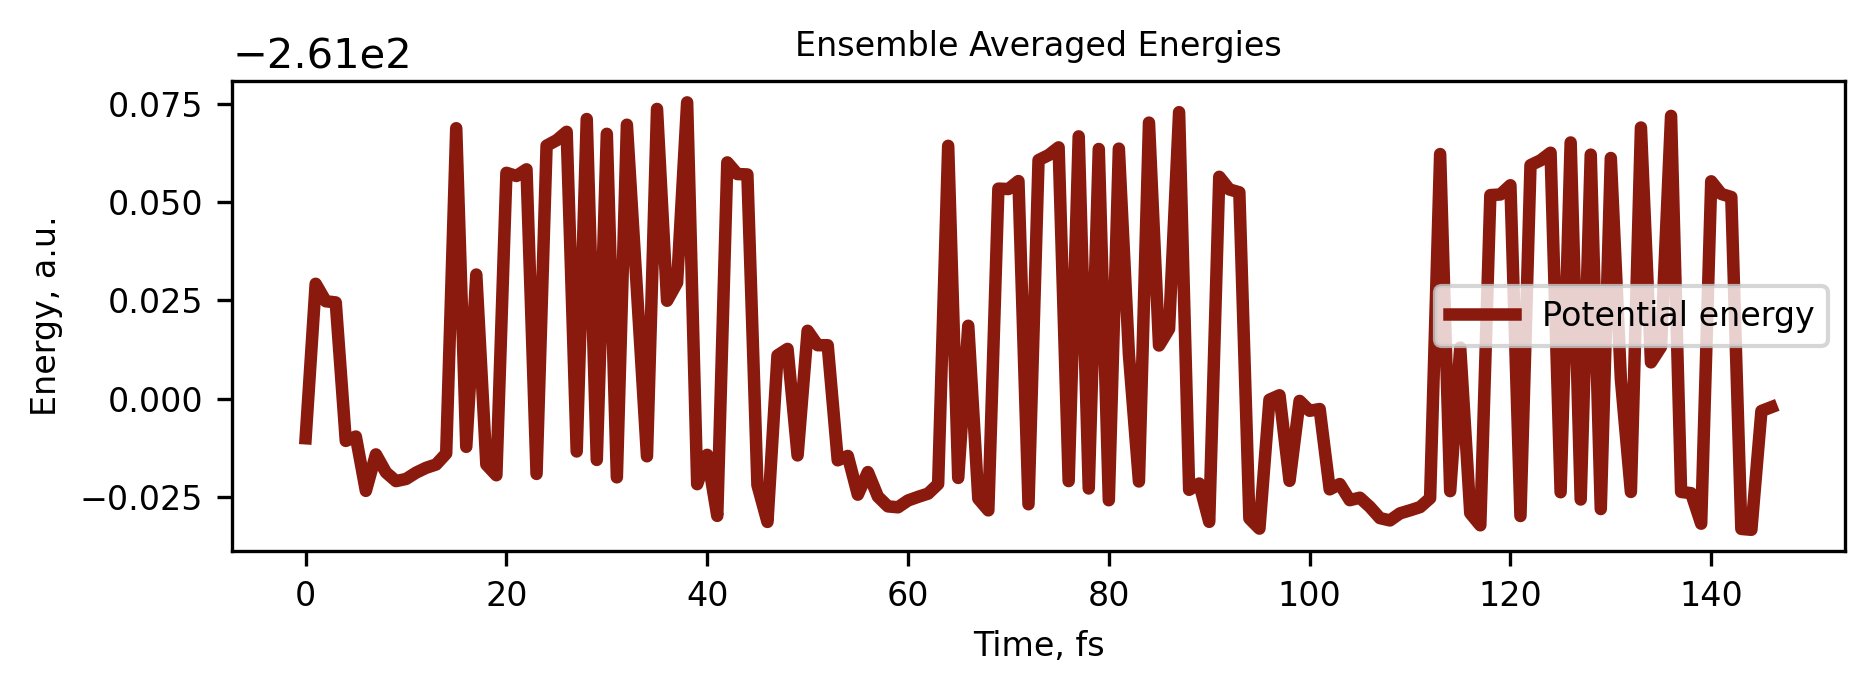

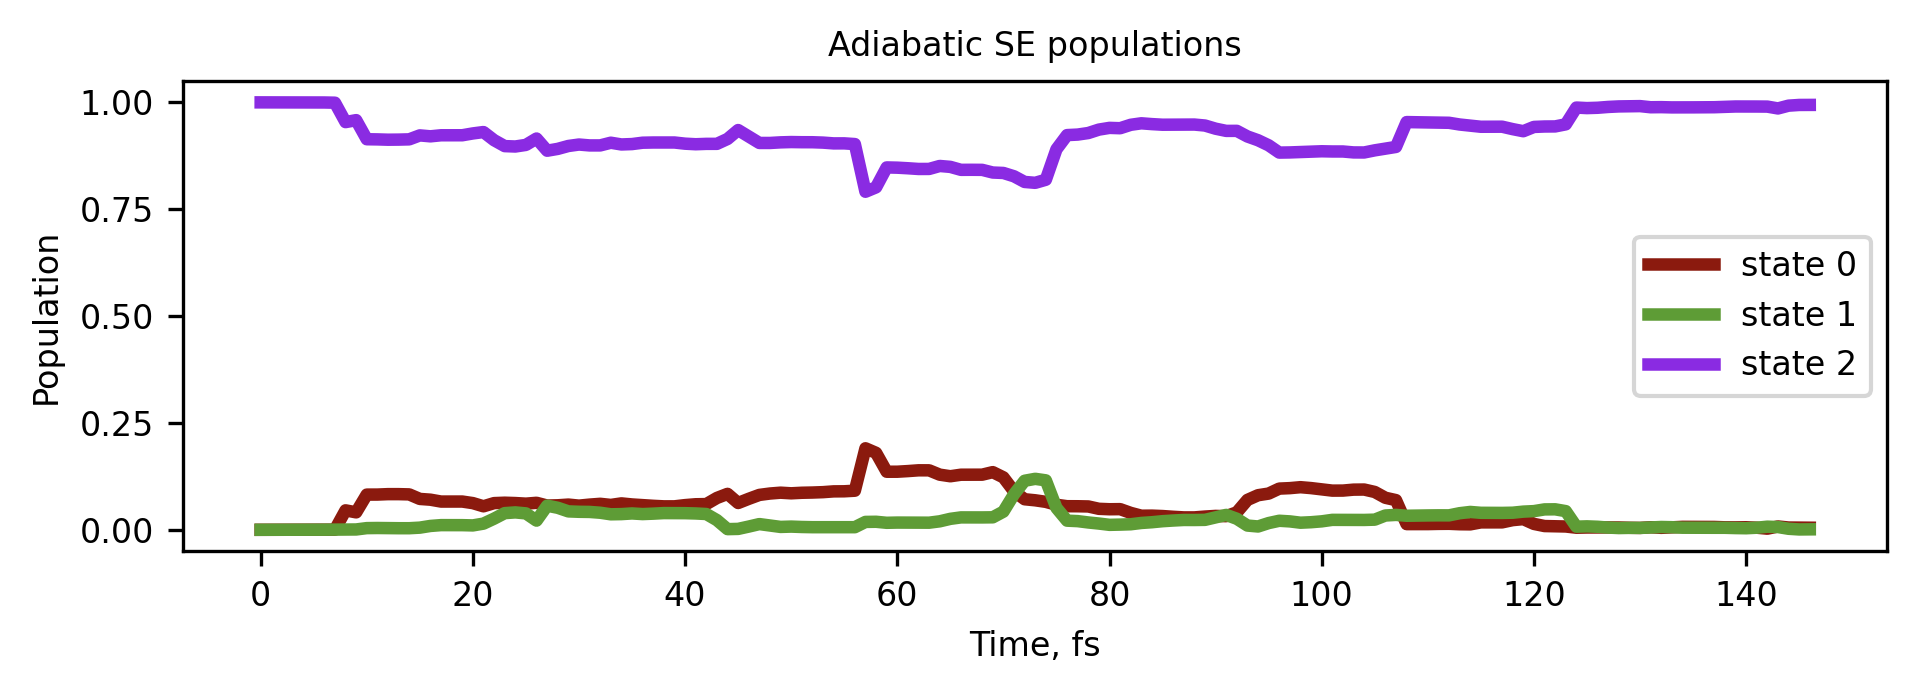

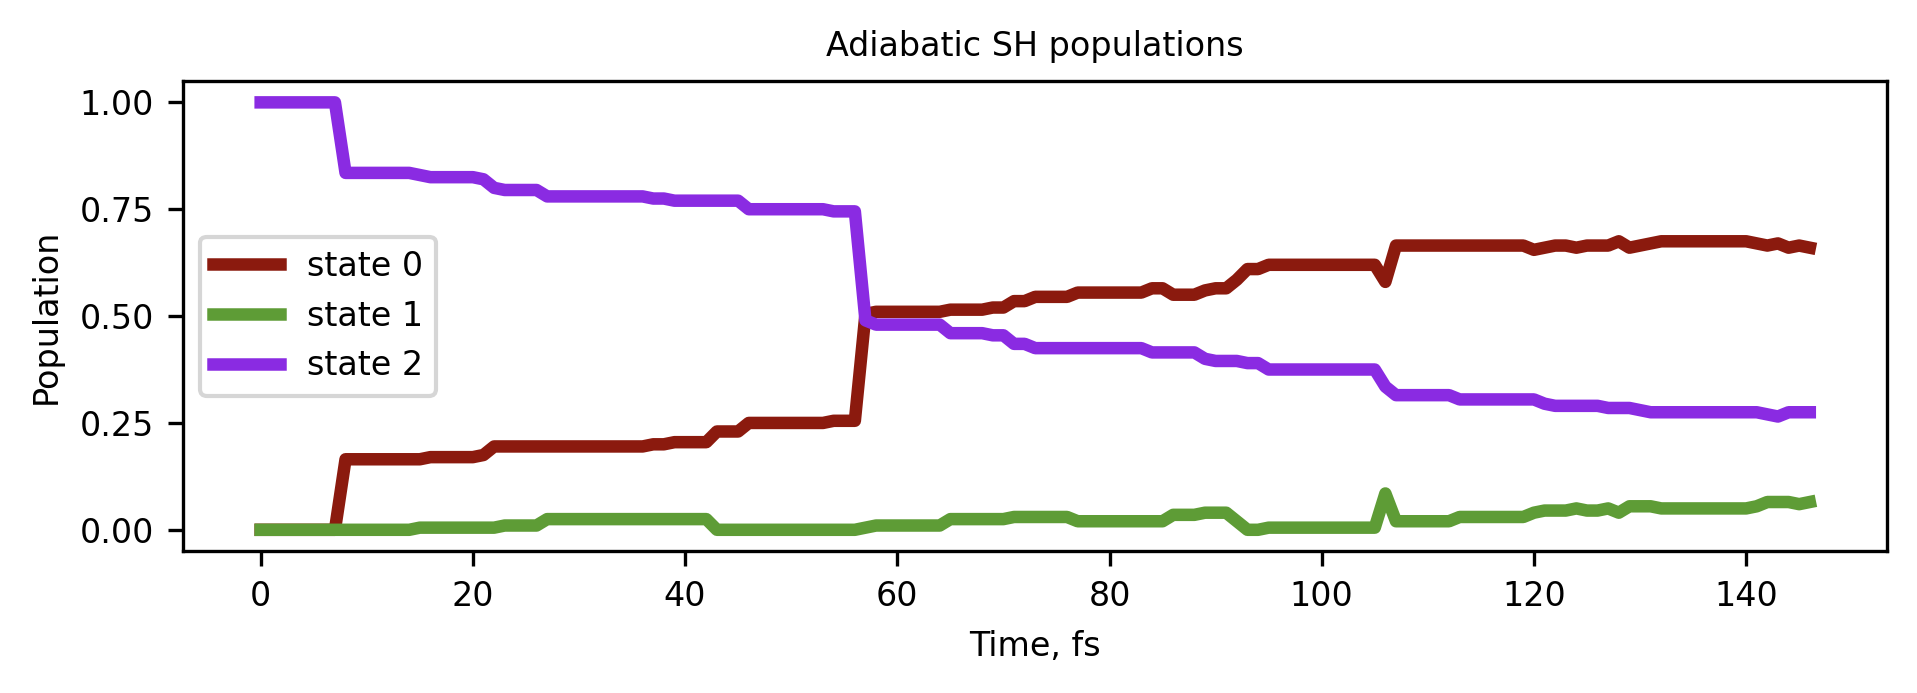

In [263]:
pref = "FSSH_NBRA_icond_0"

nst = model_params["nstates"]
ntraj = dyn_general["ntraj"]

plot_params = { "prefix":pref, "filename":"mem_data.hdf", "output_level":2,
                "which_trajectories":list(range(ntraj)), "which_dofs":[0], "which_adi_states":list(range(nst)), 
                "which_dia_states":list(range(nst)), 
                "frameon":True, "linewidth":3, "dpi":300,
                "axes_label_fontsize":(8,8), "legend_fontsize":8, "axes_fontsize":(8,8), "title_fontsize":8,
                "what_to_plot":["se_pop_adi", "sh_pop_adi", "energies" ], 
                "which_energies":["potential"],
                "save_figures":1, "do_show":1
              }

tsh_dynamics_plot.plot_dynamics(plot_params)

Average decoherence times map

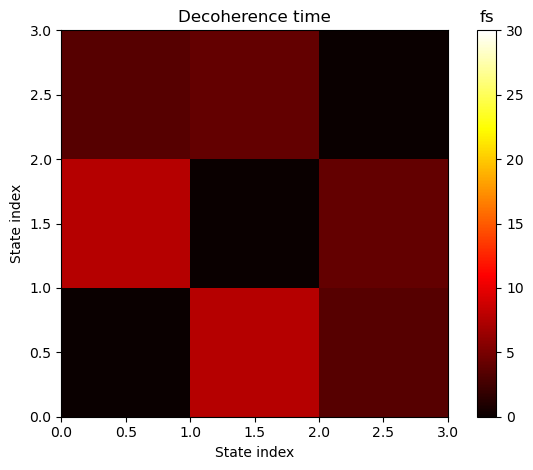

In [264]:
plt.figure()
avg_deco = np.loadtxt('decoherence_times.txt')
nstates = avg_deco.shape[0]
plt.imshow(np.flipud(avg_deco), cmap='hot', extent=(0,nstates,0,nstates))#, vmin=0, vmax=100)
plt.xlabel('State index')
plt.ylabel('State index')
colorbar = plt.colorbar()
colorbar.ax.set_title('fs')
plt.clim(vmin=0, vmax=30)
plt.title(F'Decoherence time')
plt.tight_layout()
plt.show()

Computing lifetimes

Processing data from the consecutive run:

Method: FSSH, IC 0, Tau: 101.17, Beta: 1.11, R2 = 0.9424809304719571
The number of successful runs = 1
Timescales for FSSH: 0.101 + 0.000 ps, Beta: 1.111 + 0.000


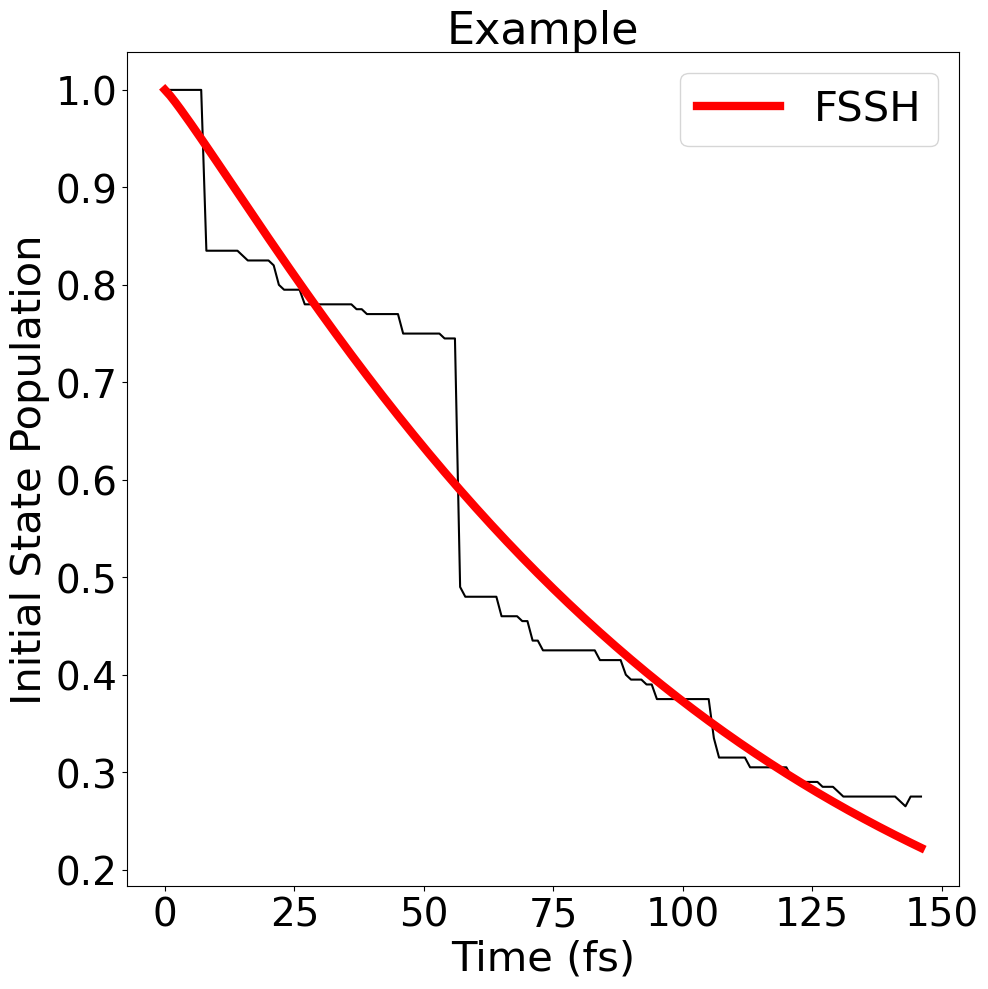

In [265]:
#Computing lifetimes
# Define function with beta optimization
def exp_funct(t, _x, beta):
    #return 1 - np.exp(-np.power(t / _x, beta)) # for ground state
    return np.exp(-np.power(t / _x, beta)) # for initial state

# Create a single figure
fig, ax = plt.subplots(figsize=(10, 10))  # Single subplot for combined plot

methods = ['FSSH']#,  'MSDM', 'FSSH2']
colors = ['red']#, 'green', 'black']  # Unique colors for each method

# Store timescale strings for both methods
timescale_labels = []

# Loop over methods and apply different exponential functions based on the method
for idx, method in enumerate(methods):
    taus = []
    betas = []

    for icond in ICONDS:
        try:
            # Load data safely
            with h5py.File(f'{method}_NBRA_icond_{icond}/mem_data.hdf', 'r') as F:
                #sh_pop = np.array(F['sh_pop_adi/data'][:, 0])
                sh_pop = np.array(F['sh_pop_adi/data'][:, ISTATE])
                #sh_pop2 = np.array(F['sh_pop_adi/data'][:, ISTATE+1])
                #sh_pop3 = np.array(F['sh_pop_adi/data'][:, ISTATE+2])
                #sh_pop = np.array(F['sh_pop_adi/data'][:, 0])
                md_time = np.array(F['time/data'][:]) * units.au2fs
                
                ax.plot(md_time, sh_pop, color="black")
                #ax.plot(md_time, sh_pop2, color="blue")
                #ax.plot(md_time, sh_pop3, color="green")
                

            # Initial guesses: tau = 100 fs, beta = 1 (exponential)
            p0 = [100.0, 1.0]

            # Fit data using exp_funct (optimizing tau and beta)
            popt, pcov = curve_fit(exp_funct, md_time, sh_pop, p0=p0, bounds=([0.0, 0.0], [np.inf, 5.0]))
            _tau, _beta = popt

            # Compute R-squared
            residuals = sh_pop - exp_funct(md_time, *popt)
            ss_res = np.sum(residuals**2)
            ss_tot = np.sum((sh_pop - np.mean(sh_pop))**2)
            r_squared = 1.0 - (ss_res / ss_tot)

            print(f"Method: {method}, IC {icond}, Tau: {_tau:.2f}, Beta: {_beta:.2f}, R2 = {r_squared}")

            if r_squared > 0.0:
                taus.append(_tau)
                betas.append(_beta)

        except Exception as e:
            print(f"Error processing {method}, IC {icond}: {e}")
            continue
           
    N = 0
    if len(taus) > 0:
        taus = np.array(taus)
        betas = np.array(betas)
        ave_tau = np.average(taus)
        ave_beta = np.average(betas)
        s_tau = np.std(taus)
        s_beta = np.std(betas)
        Z = 1.96
        N = len(taus)
        error_tau = Z * s_tau / np.sqrt(N)
        error_beta = Z * s_beta / np.sqrt(N)
    else:
        ave_tau, error_tau, ave_beta, error_beta = 0, 0, 0, 0  # Default if no data
        
    print(F"The number of successful runs = {N}")

    # Convert timescale to ps
    ave_tau_ps = ave_tau / 1000
    error_tau_ps = error_tau / 1000
    print(f'Timescales for {method}: {ave_tau_ps:.3f} + {error_tau_ps:.3f} ps, Beta: {ave_beta:.3f} + {error_beta:.3f}')

    timescale_labels.append(f"{method}: {ave_tau_ps:.3f} +  {error_tau_ps:.3f} ps, Beta = {ave_beta:.3f} + {error_beta:.3f}")
    timescale_labels = [label.replace("MSDM", "mSDM") for label in timescale_labels]

    if N > 0:
        ax.plot(md_time, exp_funct(md_time, ave_tau - error_tau, ave_beta), ls='--', linewidth=2, color=colors[idx])
        ax.plot(md_time, exp_funct(md_time, ave_tau, ave_beta), ls='-', linewidth=6, color=colors[idx], label=f"{method}")
        ax.plot(md_time, exp_funct(md_time, ave_tau + error_tau, ave_beta), ls='--', linewidth=2, color=colors[idx])
        
ax.set_xlabel("Time (fs)", fontsize=30)
ax.set_ylabel("Initial State Population", fontsize=30)
ax.set_title("Example", fontsize=32)
ax.legend(fontsize=30)
ax.tick_params(axis='both', which='major', labelsize=28)

# Add timescale text
timescale_text = "\n".join(timescale_labels)
props = dict(boxstyle='round', facecolor='white', alpha=0.8)

# Save and show plot
#plt.savefig('GS_pop_recovery_TiO2_4_300K.png', dpi=600, bbox_inches='tight', transparent=True)
plt.tight_layout()
plt.show()

Same code - but processing data from the multithreading run:

The point here is to check whether the multithreading produces the same results and consecutive execution of the calculation. If some race conditions or unintended data sharing across different trajectories is happenining, it may affect the outcomes of the multithreading calculations. However, this doesn't seem to be happening, which is good

Method: FSSH, IC 0, Tau: 96.73, Beta: 0.92, R2 = 0.9403189093038827
The number of successful runs = 1
Timescales for FSSH: 0.097 + 0.000 ps, Beta: 0.923 + 0.000


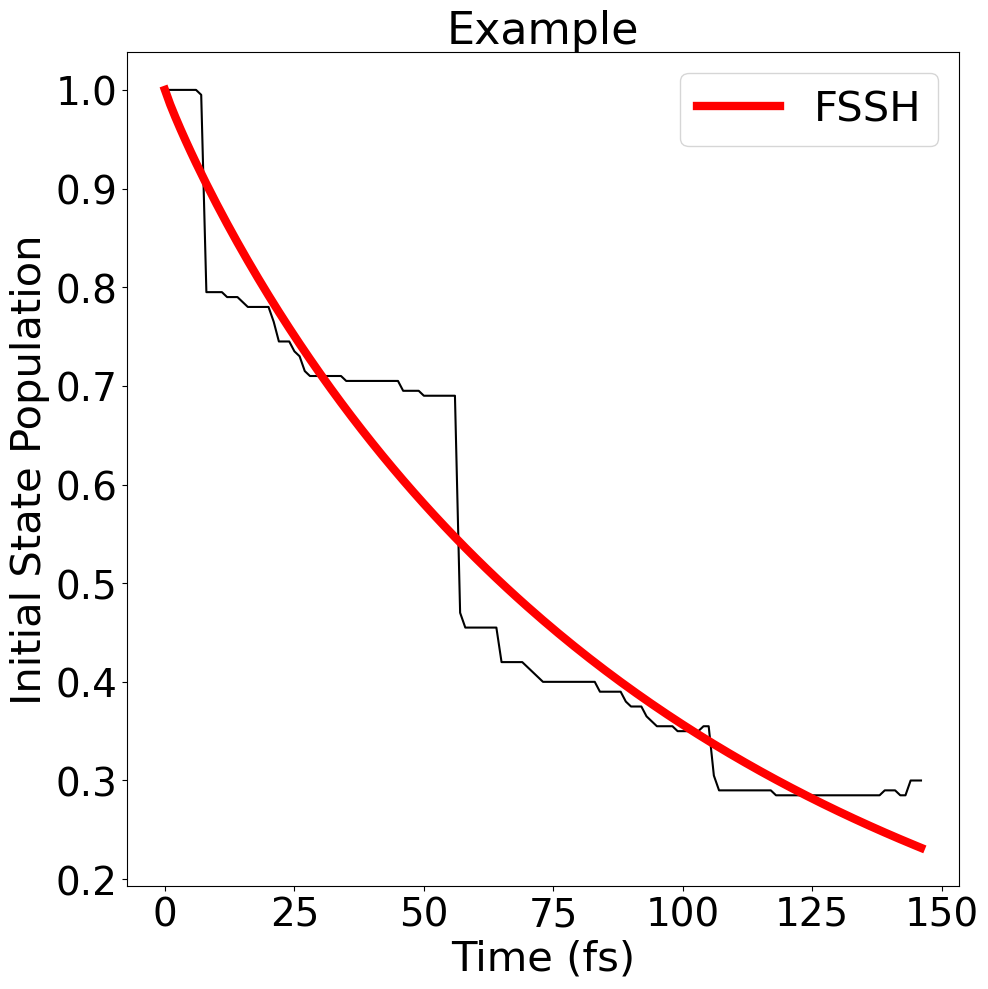

In [266]:
# Same code - but processing data from the multithreading run:
# Define function with beta optimization
def exp_funct(t, _x, beta):
    #return 1 - np.exp(-np.power(t / _x, beta)) # for ground state
    return np.exp(-np.power(t / _x, beta)) # for initial state

# Create a single figure
fig, ax = plt.subplots(figsize=(10, 10))  # Single subplot for combined plot

methods = ['FSSH']#,  'MSDM', 'FSSH2']
colors = ['red']#, 'green', 'black']  # Unique colors for each method

# Store timescale strings for both methods
timescale_labels = []

# Loop over methods and apply different exponential functions based on the method
for idx, method in enumerate(methods):
    taus = []
    betas = []

    for icond in ICONDS:
        try:
            # Load data safely
            with h5py.File(f'{method}_icond_{icond}/mem_data.hdf', 'r') as F:
                #sh_pop = np.array(F['se_pop_adi/data'][:, 0])
                sh_pop = np.array(F['sh_pop_adi/data'][:, ISTATE])
                #sh_pop2 = np.array(F['sh_pop_adi/data'][:, ISTATE+1])
                #sh_pop3 = np.array(F['sh_pop_adi/data'][:, ISTATE+2])
                #sh_pop = np.array(F['sh_pop_adi/data'][:, 0])
                md_time = np.array(F['time/data'][:]) * units.au2fs
                
                ax.plot(md_time, sh_pop, color="black")
                #ax.plot(md_time, sh_pop2, color="blue")
                #ax.plot(md_time, sh_pop3, color="green")
                

            # Initial guesses: tau = 100 fs, beta = 1 (exponential)
            p0 = [100.0, 1.0]

            # Fit data using exp_funct (optimizing tau and beta)
            popt, pcov = curve_fit(exp_funct, md_time, sh_pop, p0=p0, bounds=([0.0, 0.0], [np.inf, 5.0]))
            _tau, _beta = popt

            # Compute R-squared
            residuals = sh_pop - exp_funct(md_time, *popt)
            ss_res = np.sum(residuals**2)
            ss_tot = np.sum((sh_pop - np.mean(sh_pop))**2)
            r_squared = 1.0 - (ss_res / ss_tot)

            print(f"Method: {method}, IC {icond}, Tau: {_tau:.2f}, Beta: {_beta:.2f}, R2 = {r_squared}")

            if r_squared > 0.0:
                taus.append(_tau)
                betas.append(_beta)

        except Exception as e:
            print(f"Error processing {method}, IC {icond}: {e}")
            continue
           
    N = 0
    if len(taus) > 0:
        taus = np.array(taus)
        betas = np.array(betas)
        ave_tau = np.average(taus)
        ave_beta = np.average(betas)
        s_tau = np.std(taus)
        s_beta = np.std(betas)
        Z = 1.96
        N = len(taus)
        error_tau = Z * s_tau / np.sqrt(N)
        error_beta = Z * s_beta / np.sqrt(N)
    else:
        ave_tau, error_tau, ave_beta, error_beta = 0, 0, 0, 0  # Default if no data
        
    print(F"The number of successful runs = {N}")

    # Convert timescale to ps
    ave_tau_ps = ave_tau / 1000
    error_tau_ps = error_tau / 1000
    print(f'Timescales for {method}: {ave_tau_ps:.3f} + {error_tau_ps:.3f} ps, Beta: {ave_beta:.3f} + {error_beta:.3f}')

    timescale_labels.append(f"{method}: {ave_tau_ps:.3f} +  {error_tau_ps:.3f} ps, Beta = {ave_beta:.3f} + {error_beta:.3f}")
    timescale_labels = [label.replace("MSDM", "mSDM") for label in timescale_labels]

    if N > 0:
        ax.plot(md_time, exp_funct(md_time, ave_tau - error_tau, ave_beta), ls='--', linewidth=2, color=colors[idx])
        ax.plot(md_time, exp_funct(md_time, ave_tau, ave_beta), ls='-', linewidth=6, color=colors[idx], label=f"{method}")
        ax.plot(md_time, exp_funct(md_time, ave_tau + error_tau, ave_beta), ls='--', linewidth=2, color=colors[idx])
        
ax.set_xlabel("Time (fs)", fontsize=30)
ax.set_ylabel("Initial State Population", fontsize=30)
ax.set_title("Example", fontsize=32)
ax.legend(fontsize=30)
ax.tick_params(axis='both', which='major', labelsize=28)

# Add timescale text
timescale_text = "\n".join(timescale_labels)
props = dict(boxstyle='round', facecolor='white', alpha=0.8)

# Save and show plot
#plt.savefig('GS_pop_recovery_TiO2_4_300K.png', dpi=600, bbox_inches='tight', transparent=True)
plt.tight_layout()
plt.show()

# Additional descriptive analysis: Pre-dynamics

Convert the matrices to NumPy for convenience

In [267]:
numpy_st_adi = np.zeros( (NSTEPS, NSTATES, NSTATES) )
numpy_ham_adi = np.zeros( (NSTEPS, NSTATES, NSTATES) )
numpy_nac_adi = np.zeros( (NSTEPS, NSTATES, NSTATES) )

for i in range(NSTEPS):
    numpy_st_adi[i, :, :] = data_conv.MATRIX2nparray(St_adi[i]).real
    numpy_ham_adi[i, :, :] = data_conv.MATRIX2nparray(Ham_adi[i]).real
    numpy_nac_adi[i, :, :] = data_conv.MATRIX2nparray(NAC_adi[i]).real

Excitation energies vs time  ## Needs discussion with Dr. Arshad Mehmood and Dr. Alexey Akimov for this strange behaviour. 

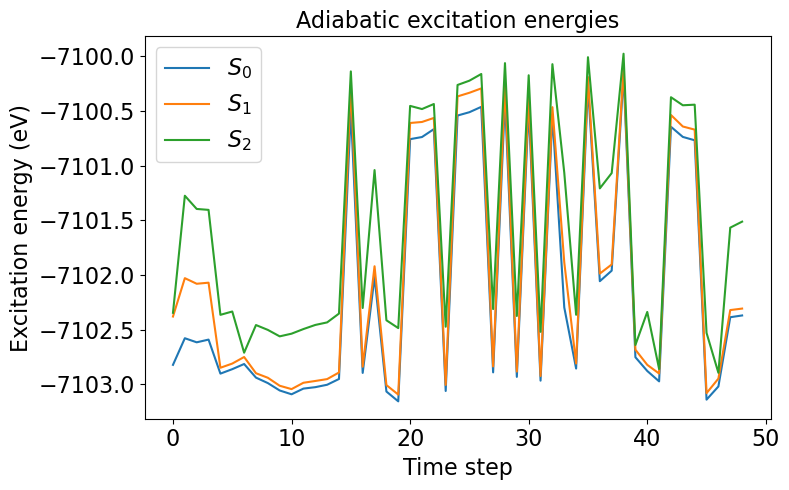

In [268]:
# ----------------------------
# Extract excitation energies
# ----------------------------
time = np.arange(0, NSTEPS)

# ----------------------------
# Plot all excitation energies
# ----------------------------
plt.figure(figsize=(8,5))
#plt.ylim(3.5,5)
for i in range(NSTATES):
    plt.plot(time, numpy_ham_adi[:, i, i]  * units.au2ev, label=f"$S_{i}$")

plt.xlabel("Time step", fontsize=16)
plt.ylabel("Excitation energy (eV)", fontsize=16)
plt.title("Adiabatic excitation energies", fontsize=16)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=16)
plt.tight_layout()
plt.show()

same but with reference to ground state

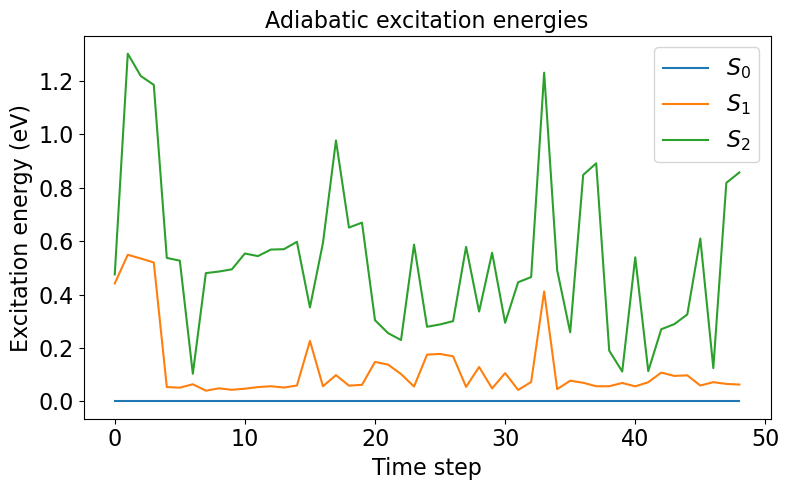

In [269]:
time = np.arange(0, NSTEPS)

plt.figure(figsize=(8,5))

E0 = numpy_ham_adi[:, 0, 0]   # ground state energy

for i in range(NSTATES):
    excitation_energy = (numpy_ham_adi[:, i, i] - E0) * units.au2ev
    plt.plot(time, excitation_energy, label=fr"$S_{i}$")

plt.xlabel("Time step", fontsize=16)
plt.ylabel("Excitation energy (eV)", fontsize=16)
plt.title("Adiabatic excitation energies", fontsize=16)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=16)
plt.tight_layout()
plt.show()

Gap distributions

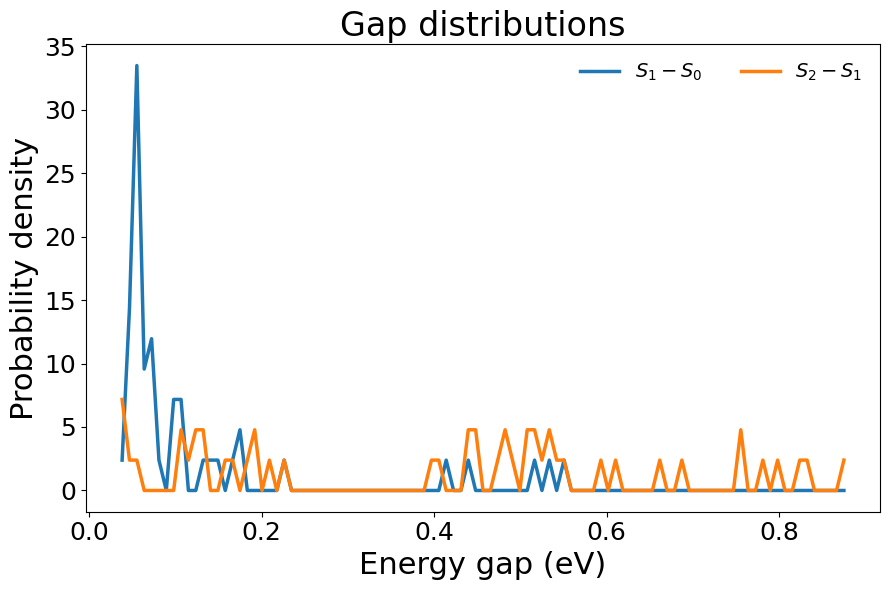

In [270]:
# Adjacent gaps
all_gaps = []
for i in range(NSTATES-1):
    all_gaps.append(numpy_ham_adi[:, i+1, i+1] - numpy_ham_adi[:, i, i])
all_gaps = np.array(all_gaps)  * units.au2ev


bins = np.linspace(np.min(all_gaps), np.max(all_gaps), 100)

plt.figure(figsize=(9,6))

for i in range(all_gaps.shape[0]):
    hist, edges = np.histogram(all_gaps[i], bins=bins, density=True)
    centers = 0.5 * (edges[:-1] + edges[1:])
    plt.plot(centers, hist, linewidth=2.5, label=f"$S_{i+1}-S_{i}$")

plt.xlabel("Energy gap (eV)", fontsize=22)
plt.ylabel("Probability density", fontsize=22)
plt.title("Gap distributions", fontsize=24)
#plt.xlim(0,0.25)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

plt.legend(ncol=2, fontsize=14, frameon=False)
plt.tight_layout()
plt.show()

NAC map

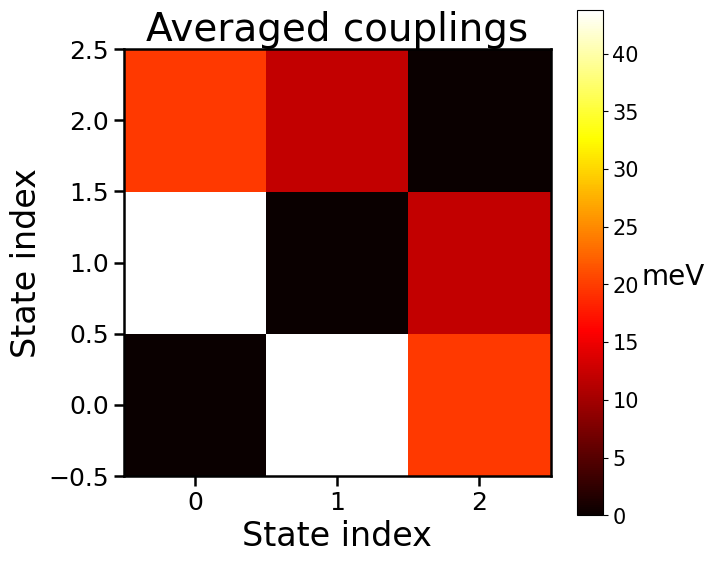

In [271]:
nacs = numpy_nac_adi #(St - np.transpose(St, (0, 2, 1))) / (2.0 * dt)
avg_coupling_meV = np.mean(np.abs(nacs), axis=0) * units.au2ev * 1000.0 # to meV
np.fill_diagonal(avg_coupling_meV, 0.0)

#nstates = avg_coupling_meV.shape[0]

# keep only pairs within |i-j| <= band
band = 8
masked = avg_coupling_meV.copy()
for i in range(NSTATES):
    for j in range(NSTATES):
        if abs(i - j) > band:
            masked[i, j] = 0.0

fig, ax = plt.subplots(figsize=(7.2, 6.2))
im = ax.imshow(masked, origin="lower", cmap="hot", interpolation="nearest", aspect="equal")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("meV", fontsize=20, rotation=0, labelpad=25)
cbar.ax.tick_params(labelsize=15)

ax.set_xlabel("State index", fontsize=24)
ax.set_ylabel("State index", fontsize=24)
ax.set_title("Averaged couplings", fontsize=28)
ax.tick_params(axis='both', which='major', labelsize=18, width=1.8, length=7)

for spine in ax.spines.values():
    spine.set_linewidth(1.8)

plt.tight_layout()
plt.show()

NAC distribution (all NAC pairs)

Number of samples: 97
min, max (meV): 6.188494431057584e-14 285.0611279862777


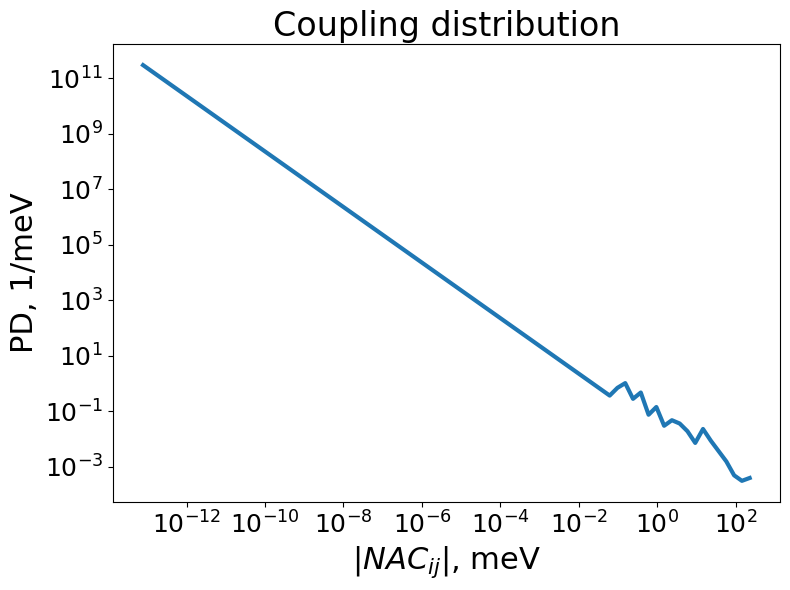

In [272]:
#NAC distribution (only adjacent pairs)
# ----------------------------
# Inputs
# ----------------------------
# nacs shape: (nsteps, nstates, nstates)

# ----------------------------
# Gather all unique pair couplings
# ----------------------------
all_couplings = []

for i in range(NSTATES-1):
    dij = np.abs(nacs[:, i, i+1])          # shape: (nsteps,)
    cij_meV = dij * units.au2ev * 1000.0 # 
    all_couplings.append(cij_meV)

all_couplings = np.concatenate(all_couplings)

# Remove exact zeros for log-scale plotting
all_couplings = all_couplings[all_couplings > 0]

print("Number of samples:", len(all_couplings))
print("min, max (meV):", np.min(all_couplings), np.max(all_couplings))

# ----------------------------
# Log-spaced bins
# ----------------------------
bins = np.logspace(
    np.log10(np.min(all_couplings)),
    np.log10(np.max(all_couplings)),
    80
)
hist, edges = np.histogram(all_couplings, bins=bins, density=True)
centers = np.sqrt(edges[:-1] * edges[1:])   # geometric centers for log bins

# Keep only nonzero histogram values
mask = hist > 0

# ----------------------------
# Plot
# ----------------------------
plt.figure(figsize=(8,6))
plt.plot(centers[mask], hist[mask], linewidth=3)

plt.xscale("log")
plt.yscale("log")

plt.xlabel(r"$|NAC_{ij}|$, meV", fontsize=22)
plt.ylabel("PD, 1/meV", fontsize=22)
plt.title("Coupling distribution", fontsize=24)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.tight_layout()
plt.show()

NAC distribution (only adjacent pairs)

Number of samples: 134
min, max (meV): 0.11050452991708606 285.0611279862777


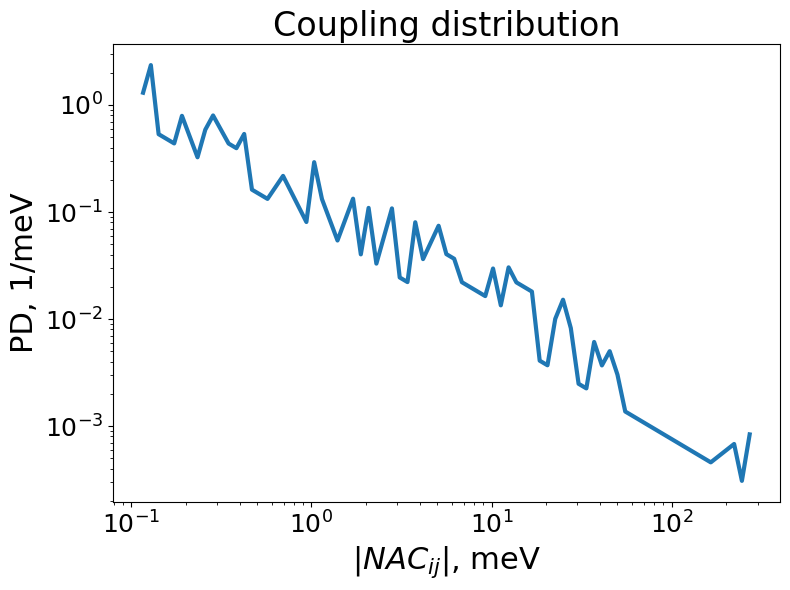

In [273]:
#NAC distribution (all NAC pairs)
# ----------------------------
# Inputs
# ----------------------------
# nacs shape: (nsteps, nstates, nstates)

# ----------------------------
# Gather all unique pair couplings
# ----------------------------
all_couplings = []

for i in range(NSTATES):
    for j in range(i + 1, NSTATES):
        dij = np.abs(nacs[:, i, j])          # shape: (nsteps,)
        cij_meV = dij * units.au2ev * 1000.0 # 
        all_couplings.append(cij_meV)

all_couplings = np.concatenate(all_couplings)

# Remove exact zeros for log-scale plotting
all_couplings = all_couplings[all_couplings > 1E-1]

print("Number of samples:", len(all_couplings))
print("min, max (meV):", np.min(all_couplings), np.max(all_couplings))

# ----------------------------
# Log-spaced bins
# ----------------------------
bins = np.logspace(
    np.log10(np.min(all_couplings)),
    np.log10(np.max(all_couplings)),
    80
)
hist, edges = np.histogram(all_couplings, bins=bins, density=True)
centers = np.sqrt(edges[:-1] * edges[1:])   # geometric centers for log bins

# Keep only nonzero histogram values
mask = hist > 0

# ----------------------------
# Plot
# ----------------------------
plt.figure(figsize=(8,6))
plt.plot(centers[mask], hist[mask], linewidth=3)

plt.xscale("log")
plt.yscale("log")

plt.xlabel(r"$|NAC_{ij}|$, meV", fontsize=22)
plt.ylabel("PD, 1/meV", fontsize=22)
plt.title("Coupling distribution", fontsize=24)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.tight_layout()
plt.show()

Time-overlaps diagnostics

If the determinant of the time-overlap matrix is close to zero (or just very small) at some points - this indicates that some of the states may be projecting outside of the selected basis of excited states. In these situations, using LD integrators may be dangerous.

You can vary the nact_st below to see for which value the determinant is not close to zero. This may suggest what active space of CI excitations to use

In [274]:
#Time-overlaps diagnostics
for nact_st in range(1, NSTATES+1):
    min_val = np.min( np.abs( np.linalg.det(numpy_st_adi[:,:nact_st,:nact_st]) ) ) 
    print(F"nact_st = {nact_st}, min_val = {min_val}")

nact_st = 1, min_val = 0.0001670097100000001
nact_st = 2, min_val = 1.8306268111843482e-08
nact_st = 3, min_val = 1.200979837261847e-13


As we can see, the larger number of excited states stored in the time-overlap matrix generally leads to a decreased determinant of this matrix

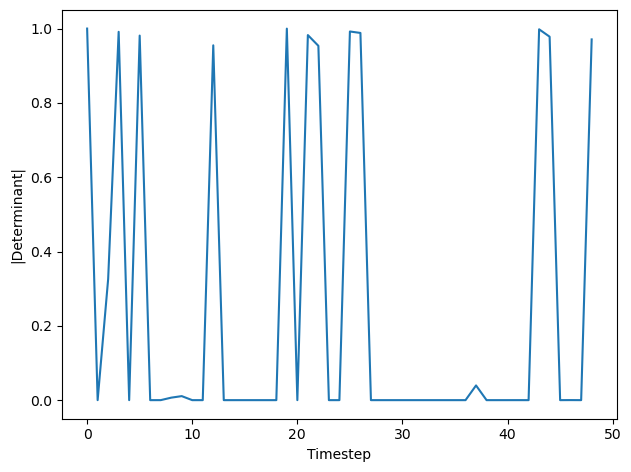

In [275]:
nact_st = 11

plt.figure(figsize=(3.21*2,2.41*2))
determinants = []
for i in range(NSTEPS):
    determinants.append(np.linalg.det(numpy_st_adi[i][:nact_st,:nact_st]  )) 
plt.plot(np.arange(len(determinants)), np.abs(determinants))
plt.xlabel('Timestep')
plt.ylabel('|Determinant|')
plt.tight_layout()
plt.show()